In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Data Exploration
|

In [7]:



df_raw = pd.read_csv('train.csv')

df_raw.head()






,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df_raw.shape

(891, 12)

In [12]:
df_raw.select_dtypes(include='number').columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [13]:
df_raw.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [14]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
df_raw.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
df_raw.isnull().values.any()

np.True_

In [23]:
df_filtered = df_raw.loc[:, df_raw.isnull().any()]
print(df_filtered)

      Age Cabin Embarked
0    22.0   NaN        S
1    38.0   C85        C
2    26.0   NaN        S
3    35.0  C123        S
4    35.0   NaN        S
..    ...   ...      ...
886  27.0   NaN        S
887  19.0   B42        S
888   NaN   NaN        S
889  26.0  C148        C
890  32.0   NaN        Q

[891 rows x 3 columns]


# STEP 2: FEATURE ENGINEERING

In [35]:
df = df_raw.copy()

# 1. Feature Engineering: Title Extraction
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
rare_titles = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
df['Title'] = df['Title'].map(title_mapping).fillna(0)

# 2. Feature Engineering: Cabin Deck extraction
# We extract the first letter or use 'U' for Unknown
df['Deck'] = df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')
deck_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "T": 8, "U": 0}
df['Deck'] = df['Deck'].map(deck_mapping)

# 3. Feature Engineering: Family Size & IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1536/916937292.py:4: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Removing null values

In [36]:


print("\n Missing Values Count Before Cleaning:")
print(df_raw[['Age', 'Cabin', 'Embarked']].isnull().sum())


 Missing Values Count Before Cleaning:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [37]:



# 4. Data Cleaning: Impute Missing Values
df['Age'] = df.groupby(['Pclass', 'Title'])['Age'].transform(lambda x: x.fillna(x.median()))
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 5. Map String Categories to Numeric
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Drop raw non-numeric columns (Notice 'Cabin' is dropped, but 'Deck' is kept)
features_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']
df_clean = df.drop(columns=features_to_drop)




In [38]:
print(f" Cleaned Dataset Shape: {df_clean.shape}")


 Cleaned Dataset Shape: (891, 10)


In [33]:
print("data set after engineering and mapping ")
print(df_clean.head())

data set after engineering and mapping 
   Survived  Pclass  Sex   Age     Fare  Embarked  Title  Deck  FamilySize  \
0         0       3    1  22.0   7.2500         0      1     0           2   
1         1       1    0  38.0  71.2833         1      3     3           2   
2         1       3    0  26.0   7.9250         0      2     0           1   
3         1       1    0  35.0  53.1000         0      3     3           2   
4         0       3    1  35.0   8.0500         0      1     0           1   

   IsAlone  
0        0  
1        0  
2        1  
3        0  
4        1  


In [34]:
print(" Missing Values Count After Cleaning:")
print(df_clean.isnull().sum())


 Missing Values Count After Cleaning:
Survived      0
Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
Title         0
Deck          0
FamilySize    0
IsAlone       0
dtype: int64


visualization

/tmp/ipykernel_1536/1116555814.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Female', 'Male'])
/tmp/ipykernel_1536/1116555814.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['With Family', 'Alone'])


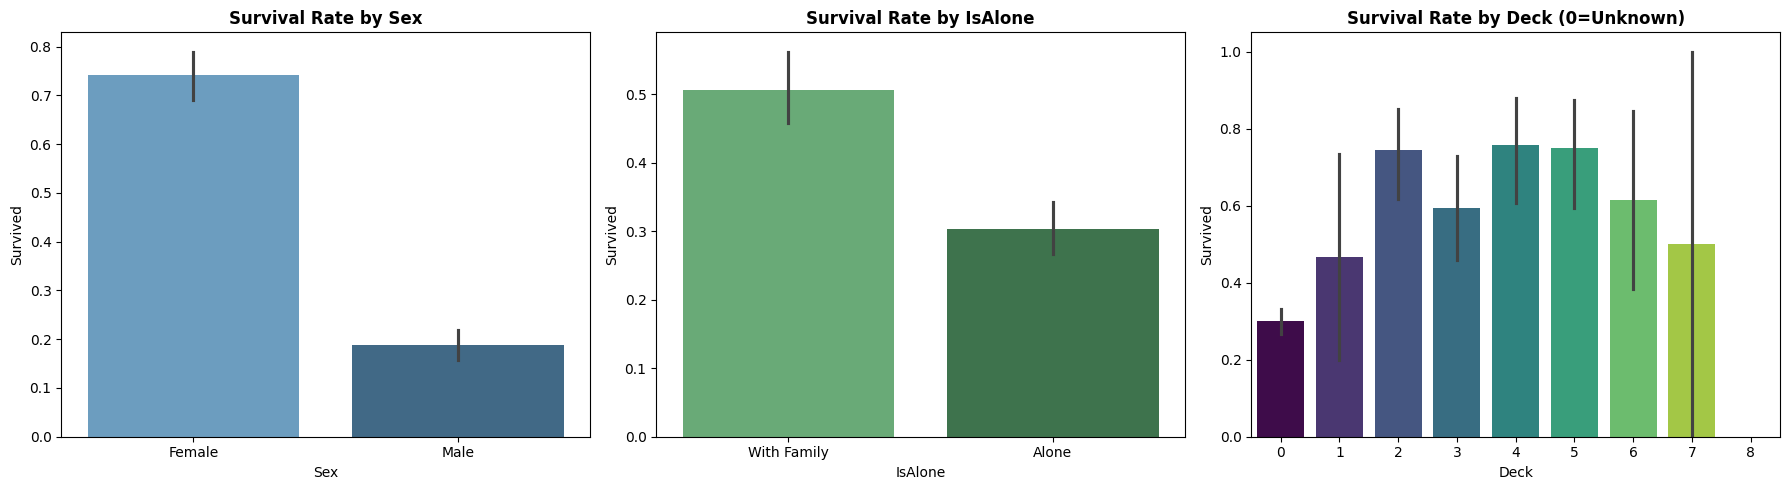

In [39]:
# --- VISUALIZATION 1: Survival by Sex, IsAlone, and Deck ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x='Sex', y='Survived', data=df_clean, ax=axes[0], palette='Blues_d', hue='Sex', legend=False)
axes[0].set_title('Survival Rate by Sex', fontweight='bold')
axes[0].set_xticklabels(['Female', 'Male'])

sns.barplot(x='IsAlone', y='Survived', data=df_clean, ax=axes[1], palette='Greens_d', hue='IsAlone', legend=False)
axes[1].set_title('Survival Rate by IsAlone', fontweight='bold')
axes[1].set_xticklabels(['With Family', 'Alone'])

sns.barplot(x='Deck', y='Survived', data=df_clean, ax=axes[2], palette='viridis', hue='Deck', legend=False)
axes[2].set_title('Survival Rate by Deck (0=Unknown)', fontweight='bold')

plt.tight_layout()
plt.show()

Data Analysis

Survived
0    549
1    342
Name: count, dtype: int64


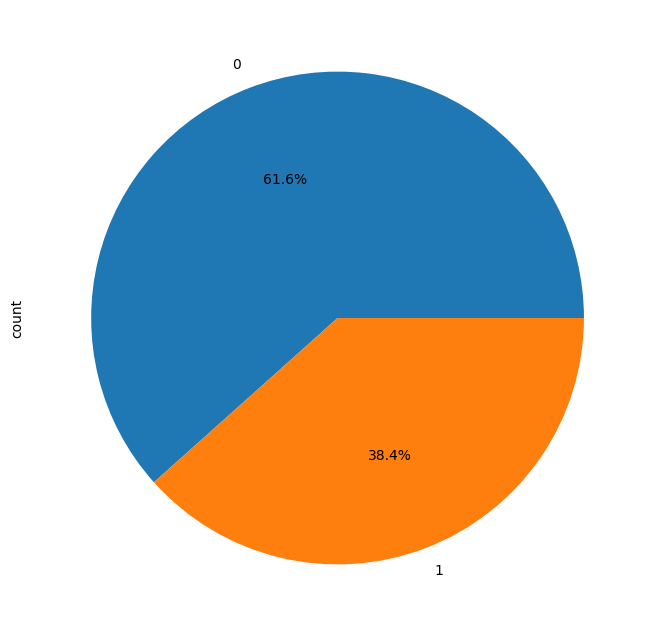

In [41]:

value_counts=df_clean['Survived'].value_counts()
print(value_counts)
plt.figure(figsize=(8,8))
value_counts.plot.pie(autopct='%1.1f%%')
plt.show()


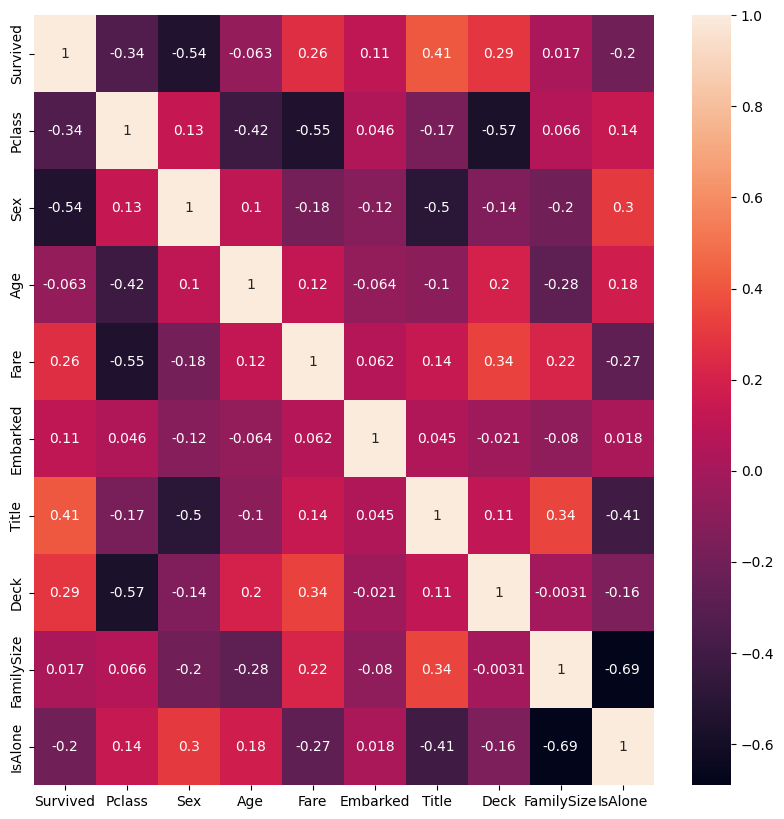

In [43]:

import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(df_clean.corr(),annot=True)
plt.show()

### Feature Importance via Mutual Information
Now we will use `mutual_info_classif` to see which features provide the most information to our model.

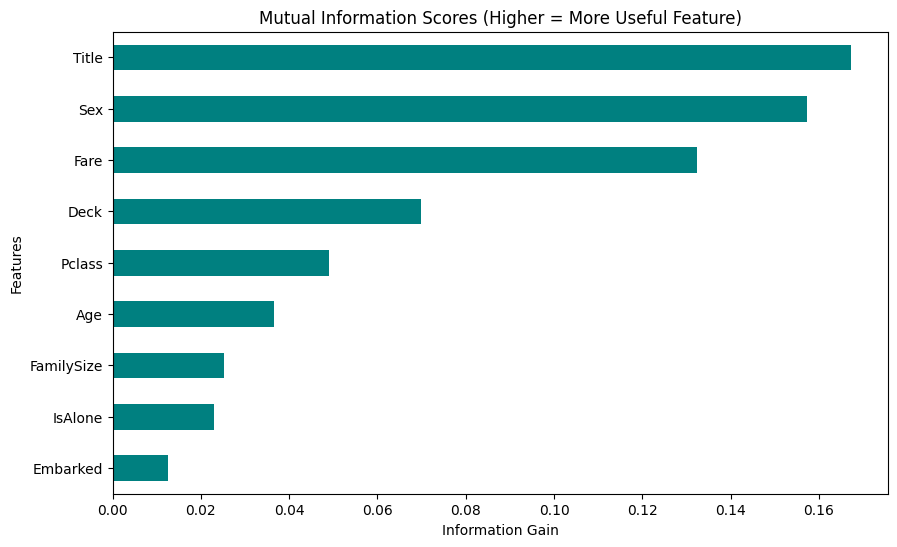

Mutual Information Scores:
Title         0.167218
Sex           0.157229
Fare          0.132343
Deck          0.069929
Pclass        0.048909
Age           0.036521
FamilySize    0.025156
IsAlone       0.022923
Embarked      0.012608
dtype: float64


In [44]:
from sklearn.feature_selection import mutual_info_classif

X_mi = df_clean.drop(columns=['Survived'])
y_mi = df_clean['Survived']


mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)

# Create a Series for easy plotting
mi_series = pd.Series(mi_scores, index=X_mi.columns)
mi_series = mi_series.sort_values(ascending=False)

# Plotting the results
plt.figure(figsize=(10, 6))
mi_series.plot(kind='barh', color='teal')
plt.title("Mutual Information Scores (Higher = More Useful Feature)")
plt.xlabel("Information Gain")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

print("Mutual Information Scores:")
print(mi_series)

TRAIN/TEST SPLIT

In [47]:


X = df_clean.drop(columns=['Survived']).values
y = df_clean['Survived'].values

np.random.seed(42)
shuffle_idx = np.random.permutation(len(X))
test_size = int(len(X) * 0.2)

X_train, y_train = X[shuffle_idx[test_size:]], y[shuffle_idx[test_size:]]
X_test, y_test = X[shuffle_idx[:test_size]], y[shuffle_idx[:test_size]]

print(f" Training Samples: {X_train.shape[0]} rows | {X_train.shape[1]} features")
print(f" Testing Samples:  {X_test.shape[0]} rows | {X_test.shape[1]} features")

 Training Samples: 713 rows | 9 features
 Testing Samples:  178 rows | 9 features


In [48]:
# STEP 4: DECISION TREE CLASSES WITH LOGGING
# ==========================================
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None


class DecisionTreeFromScratch:
    def __init__(self, min_samples_split=2, max_depth=100):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        print("\n Starting Decision Tree Training...")
        self.root = self._build_tree(X, y, depth=0)
        print(" Training Complete! Tree built successfully.")

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))

        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_val = self._most_common_label(y)
            return Node(value=leaf_val)

        best_feature, best_threshold = self._best_split(X, y, n_features)

        if best_feature is None:
            return Node(value=self._most_common_label(y))

        left_idxs, right_idxs = self._split(X[:, best_feature], best_threshold)

        # Log early root splits so you can see the top rules being created!
        if depth < 2:
            print(f"  [Depth {depth} Split] Feature Index {best_feature} <= {best_threshold:.2f} | Left Child: {len(left_idxs)} samples, Right Child: {len(right_idxs)} samples")

        left_child = self._build_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right_child = self._build_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return Node(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def _best_split(self, X, y, n_features):
        best_gain = -1
        split_idx, split_threshold = None, None
        parent_gini = self._gini(y)

        for feat_idx in range(n_features):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold, parent_gini)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = threshold

        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold, parent_gini):
        left_idxs, right_idxs = self._split(X_column, threshold)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        gini_l, gini_r = self._gini(y[left_idxs]), self._gini(y[right_idxs])
        child_gini = (n_l / n) * gini_l + (n_r / n) * gini_r

        return parent_gini - child_gini

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _gini(self, y):
        hist = np.bincount(y)
        probabilities = hist / len(y)
        return 1.0 - np.sum(probabilities ** 2)

    def _most_common_label(self, y):
        return np.bincount(y).argmax()

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

RUN MODEL & EVALUATE


 Starting Decision Tree Training...
  [Depth 0 Split] Feature Index 5 <= 1.00 | Left Child: 419 samples, Right Child: 294 samples
  [Depth 1 Split] Feature Index 6 <= 1.00 | Left Child: 352 samples, Right Child: 67 samples
  [Depth 1 Split] Feature Index 0 <= 2.00 | Left Child: 155 samples, Right Child: 139 samples
 Training Complete! Tree built successfully.

 MODEL ACCURACY: 81.46%


/tmp/ipykernel_1536/3681829493.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Died (0)', 'Survived (1)'])


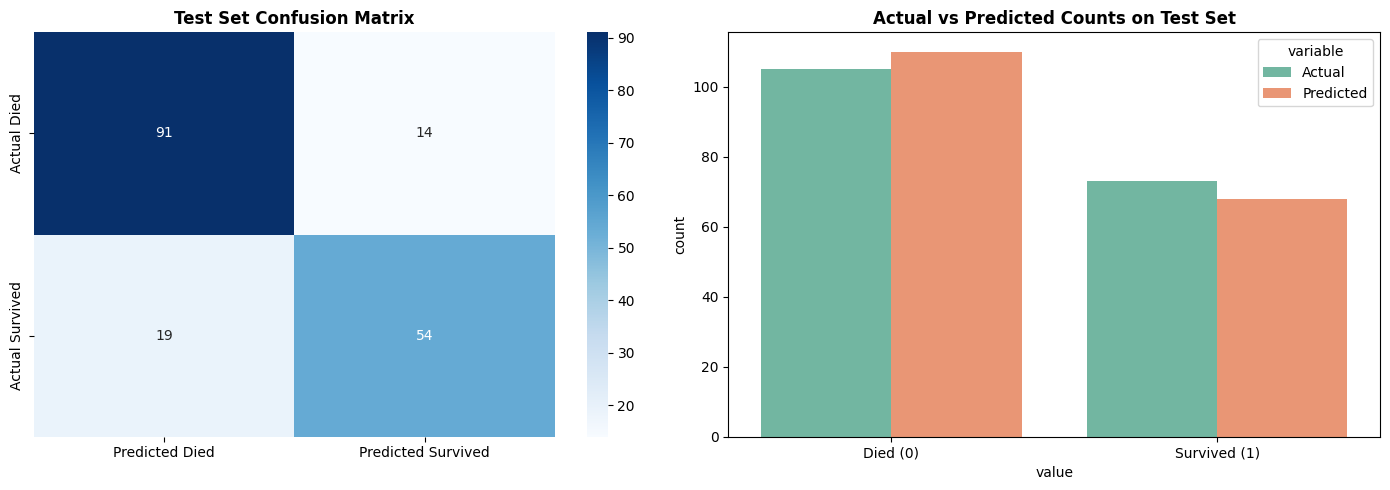

In [49]:

tree = DecisionTreeFromScratch(max_depth=5, min_samples_split=5)
tree.fit(X_train, y_train)

# Generate Predictions
predictions = tree.predict(X_test)
accuracy = np.mean(predictions == y_test) * 100

print(f"\n MODEL ACCURACY: {accuracy:.2f}%")

# --- VISUALIZATION 2: Confusion Matrix & Prediction Inspection ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
# Counts True Positive, True Negative, False Positive, False Negative
tp = np.sum((predictions == 1) & (y_test == 1))
tn = np.sum((predictions == 0) & (y_test == 0))
fp = np.sum((predictions == 1) & (y_test == 0))
fn = np.sum((predictions == 0) & (y_test == 1))

conf_matrix = np.array([[tn, fp], [fn, tp]])

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Died', 'Predicted Survived'],
            yticklabels=['Actual Died', 'Actual Survived'])
axes[0].set_title('Test Set Confusion Matrix', fontweight='bold')

# 2. Actual vs Predicted Comparison Bar
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
sns.countplot(x='value', hue='variable', data=pd.melt(results_df), ax=axes[1], palette='Set2')
axes[1].set_title('Actual vs Predicted Counts on Test Set', fontweight='bold')
axes[1].set_xticklabels(['Died (0)', 'Survived (1)'])

plt.tight_layout()
plt.show()

### Detailed Model Evaluation using Scikit-Learn Metrics
Even though we built the model from scratch, we can use standard library tools to get a detailed performance report.

In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate metrics using the predictions from your scratch model
accuracy = accuracy_score(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)
class_report = classification_report(y_test, predictions, target_names=['Died (0)', 'Survived (1)'])

print(f"--- Detailed Metrics ---")
print(f"Accuracy Score: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

--- Detailed Metrics ---
Accuracy Score: 0.8146

Confusion Matrix:
[[91 14]
 [19 54]]

Classification Report:
              precision    recall  f1-score   support

    Died (0)       0.83      0.87      0.85       105
Survived (1)       0.79      0.74      0.77        73

    accuracy                           0.81       178
   macro avg       0.81      0.80      0.81       178
weighted avg       0.81      0.81      0.81       178

